In [57]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

from PyESRSTM import units

## Quantum Dot

The quantum is represented by `QD` object, which accepts single and two electron energies, along with spin system descriptions, and solves the Hamiltonian. Below is an example of a single spin in a magnetic field.

In [58]:
from PyESRSTM import QD
#    eps[meV],U[meV],       spins,                                  Magnetic field[T],        Gyromagnetic factor
dot = QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
print(dot)

Hermiticity check passed!
idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.035209352 	-0.2 -0.0 -0.5 	-0.2 -0.0 -0.5
1	1 	-29.964790648 	0.2 0.0 0.5 	0.2 0.0 0.5
2	0 	0.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0
3	2 	40.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0


Let us print some useful attributes of the `QD` object. 

In [59]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Lambda:')
print('i,\tj,\tsigma,\tlambda')
print(dot.print_lamb())
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))


Number of spins: 1
Number of states: 4
Occupancy: [1 1 0 2]
Energies [meV]: [-30.035 -29.965   0.     40.   ]
Theta [deg]:  20.0

Lambda:
i,	j,	sigma,	lambda
0	3	0	-0.98481 + i0.00000
0	3	1	0.17365 + i0.00000
1	3	0	-0.17365 + i0.00000
1	3	1	-0.98481 + i0.00000
2	0	0	0.17365 + i0.00000
2	0	1	-0.98481 + i0.00000
2	1	0	-0.98481 + i0.00000
2	1	1	-0.17365 + i0.00000


Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.171 -0.    -0.47 ]]

 [[ 2.     1.     0.171  0.     0.47 ]]

 [[ 3.     1.     0.     0.     0.   ]]

 [[ 4.     1.     0.     0.     0.   ]]]


/home/matyas/Programs/PyESRSTM/PyESRSTM/QD/QD.py:268: ComplexWarning: Casting complex values to real discards the imaginary part
  string += '{:.0f}\t{:.0f}\t{:.0f}\t{:.5f} + i{:.5f}\n'.format(*state[:3].astype(int), np.real(state[3]), np.imag(state[3]))


## Electrodes

`Electrode` object includes all information about the electrode, also the QD broadening, for some reason. It doesn't do much beyond storing values, and calculating the Fermi integral. The grid for Fermi integral and corresponding values of the Fermi function are precalculated when the object is initialized. We will discuss the grid later when considering convergence. 

DOS= 1 , In this case very boring, but could be a function


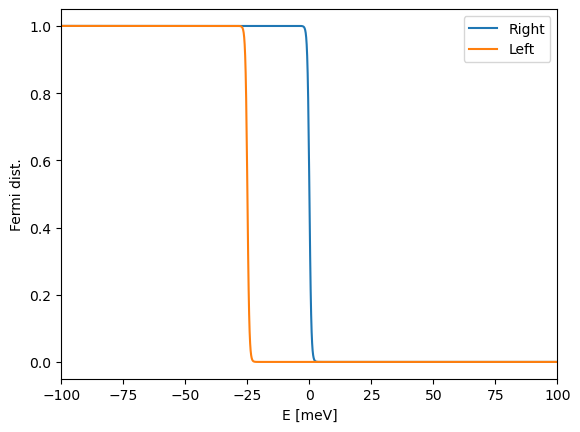

In [61]:
from PyESRSTM import Electrode
#               Vdc, VRF, P,  coupling, broadening  Temperature,
Right = Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)

fermiR = Right.fermi
enerR = Right.grid
dos = Right.dos(enerR)
print('DOS=', dos, ', In this case very boring, but could be a function')

fermiL = Left.fermi
enerL = Left.grid

plt.plot(enerR*units.Hartree, fermiR, label='Right')
plt.plot(enerL*units.Hartree, fermiL, label='Left')
plt.xlabel('E [meV]')
plt.ylabel('Fermi dist.')

plt.xlim(-100, 100)
plt.legend()
plt.show()



For A-drinving we can use the optional parameter `Adrive` 

In [62]:
Adriven = Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=.5)

## Rates

Next we combine the two to calculate the hoping rates $\Gamma$. The function `rates()` takes `QD` and `Electrode` objects, and returns their coupling, and returns two arrays containing $\Gamma^{\pm}$. We only need to aditionally specify the number of Fourier components to consider, and the frequency of driving. The former we will discuss later. The later, should not effect results as long as the frequency is small relative to the RF bias, and the energies of the quantum $\epsilon$ and $\epsilon+U$, which is mostly the case. For computinally purpuse, larger frequency will let use lower number of Bessel function, and thus speed up the calculation if RF the bias is not zero.

In [63]:
from PyESRSTM import rates, sum_rates
# The surface is static so we only look at the static component 0 Fourier components 
# The frequency is thus arbitrary and we set it to zero. 
#                      QD, Electrode, freq, NFC         
GRplus, GRminus = rates(dot,     Right, 0,   0)

# The tip is oscilating, we thus we want to keep the hi
GLplus, GLminus = rates(dot,      Left, 20,   5)

print(GRplus.shape, GLplus.shape)

(4, 4, 4, 4, 1) (4, 4, 4, 4, 11)


Since the rates have different shapes we need to be careful summing. For convinience there is a function `sum_rates()` that takes care of the difference in shape.

In [64]:
# this is safe as they are the same shape
GL = GLminus + GLplus 
GR = GRminus + GRplus

# This is wrong, but wont give an error in this case
# The constant component of GR is projected into all 5 Fourier components 
G_naive = GL + GR

# This is correct
G_correct = GL.copy()
G_correct[:,:,:,:,5] += GR[:,:,:,:,0]

# This is also correct but unecesery
# by increasing the nomber of Floquet componets we essentially pad the surface rates with zeros
GRplus_large, GRminus_large = rates(dot,     Right, 0,   5)
GR_large = GRminus_large + GRplus_large
G_brute = GL + GR_large

# This is easier and more general 
G = sum_rates(GL, GR)


print(np.all(G == G_naive), np.all(G == G_correct), np.all(G==G_brute))

False True True


### Master equation 
With the rates calculated we can now solve the master equation. We simply pass the rates to `QME()` function allong with the energies of the quantum dot, stored in `Delta` atrribute of the `QD` object. We agian need to speficy the frequency, this time it does matter since it specifies the resonance condtion. 

In [65]:
from PyESRSTM import QME, current

rho = QME(G, 20., Delta=dot.Delta)
print(rho.shape)

(4, 4, 11)


Since we often want to calculate the density matrix for different frequencies, using the same hopping rates, we can precalculate the relavant parts of the matrix being inverted using `QME_matrix()` function and pass that directly into the `QME()` function. This speed things up when scanning over a large number of frequencies, as it avoids some loops. 

In [66]:
from PyESRSTM import QME_matrix

M = QME_matrix(G, dot.Delta)
rho = QME(M, 20, qme_matrix=True)

### Curent

Calculating the current is straighforward using `current()` function. Which retruns the `2*NCF+1` components of the current. 

In [67]:
from PyESRSTM import current

GC = GLplus - GLminus
I = current(rho, GC)

print(f'DC current: {I[5]:.2f}')

DC current: -2.03+0.00j


### Dynamics desrciptos

Before we move forward we just quickly look at how we can extract some descriptors of the spin dynamics directly from rates. WARNING: these only aplly for a single spin system.

In [68]:
from PyESRSTM.postproces.dynamics import Bexch, Trel, Szacc

Lamb = Bexch(GL, GR, dot.theta)*units.Hartree/units.GHz
Bdrive = Bexch(GL, GR, dot.theta, n=1)*units.Hartree/units.GHz
T1 = Trel(GL, GR)*units.Hartree/units.GHz
Sz0 = Szacc(GL, GR, rho, Left.Spin_polarization, dot.theta)*units.Hartree/units.GHz
Sz1 = Szacc(GL, GR, rho, Left.Spin_polarization, dot.theta, n=1)*units.Hartree/units.GHz

print(f'Lamb shift: {Lamb:.4f} GHz')
print(f'Exchange Driving: {Bdrive:.4f} GHz')
print(f'STT static: {Sz0:.4f} GHz')
print(f'STT driving: {Sz1:.4f} GHz')
print(f'T1: {T1:.4f} GHz (maybe this is T2)')

Lamb shift: 0.0762 GHz
Exchange Driving: -0.0133 GHz
STT static: -0.0006 GHz
STT driving: 0.0006 GHz
T1: 0.0041 GHz (maybe this is T2)


## ESR Signal

To calculate the ESR signal we simply do the same but for a range of frequencies. This is done using `ESR.ESR()` function. We need to provide the electrodes, quantum dot a range of frequencies and how many Fourier components to use for each electrode, default is 0. The function then returns the calculated current on the first (left) electrode. However, note that all it does is loop over frequencies and calculates current. 

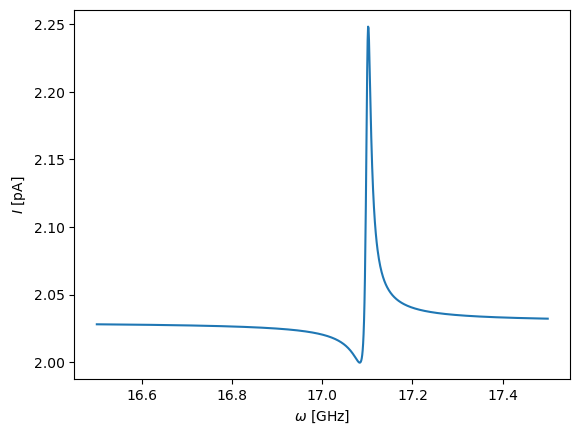

In [69]:
from PyESRSTM import ESR

freq = np.linspace(16.5, 17.5, 1000)
I = ESR.ESR(Left, Right, dot, freq, NFL=5)
# the returned signal is in the shape (len(freq), 2*NFL+1)

plt.plot(freq, I[:, 5])
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()

### Convergence with Number of integer points

Because Python is slow, we ideally want to avoid using too many points in the Fermi integral. 
With the most naive way of sampling the Fermi integral we need a considerably large number of points.  

Nint=1000: 0.68 s
Nint=3000: 0.77 s
Nint=10000: 1.15 s
Nint=30000: 2.35 s
Nint=100000: 6.13 s


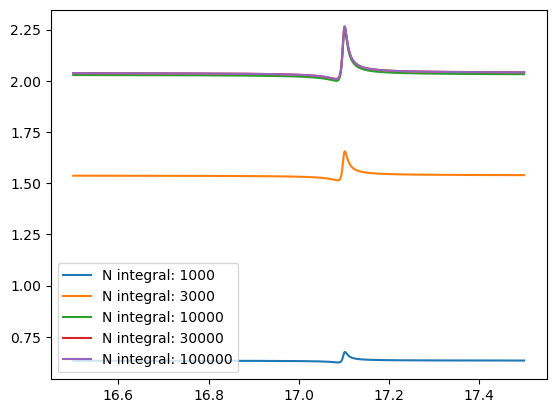

In [70]:
Nint = [1e3, 3e3, 1e4, 3e4, 1e5]

freq = np.linspace(16.5, 17.5, 1000)

NF = 2

for N in Nint:
    ts = time()
    Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=N, Cutoff=1000)
    Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=N, Cutoff=1000)

    I= ESR.ESR(Left, Right, dot, freq, NFL=NF)
    plt.plot(freq, I[:, NF], label=f'N integral: {int(N)}')

    tf = time()
    print(f'Nint={int(N):d}: {tf-ts:.2f} s')

plt.legend()
plt.show()

However the above is quite ineficient; the integrand is almost constant, except near the QD energies. Therefore we can add semgments of higher density of sammpling using the `segments` parameter of the `Electrodes`. Below we put two of these with widith 60 meV around $\epsilon$ and $U+\epsilon$. This leads to a much faster convergence. 

Nint=1000: 0.67 s
Nint=3000: 0.72 s
Nint=10000: 1.17 s
Nint=30000: 2.24 s
Nint=100000: 5.90 s


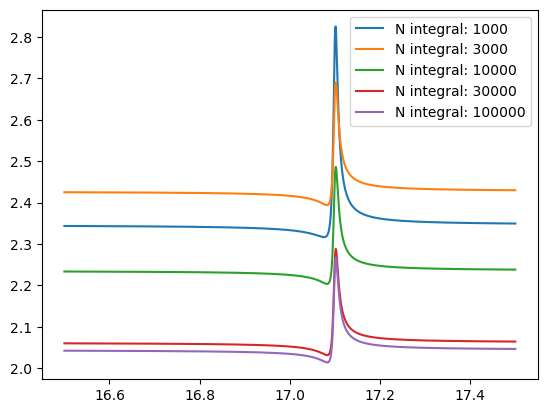

In [71]:
Nint = [1e3/3, 3e3/3, 1e4/3, 3e4/3, 1e5/3]

freq = np.linspace(16.5, 17.5, 1000)
freq = np.sort(freq)
NF = 2

for N in Nint:
    ts = time()
    Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=N, Cutoff=1000,
                      segments=[[dot.eps,30, int(N)],[dot.U+dot.eps,30,int(N)] ])
    Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=N, Cutoff=1000,
                     segments=[[dot.eps,30, int(N)],[dot.U+dot.eps,30,int(N)] ])

    I= ESR.ESR(Left, Right, dot, freq, NFL=NF)
    plt.plot(freq, I[:, NF], label=f'N integral: {int(3*N)}')

    tf = time()
    print(f'Nint={int(3*N):d}: {tf-ts:.2f} s')

plt.legend()
plt.show()

### Convergence with Fourier Componets

The number of Fourier `NF` components affects the dimensoinality of the tensor $\Gamma$, and ideally we want to minimize it. The test below shows that resnonance at frequecny requires some minimum value of Fourier components, higher resonance results from faster oscillations. However, once the resonance is captured further Fourier components do not affect it. 

The ESR signal is now normalized by subtracting from a QD under a much largem magnetic field, so only resonance feautures, are vissible (also difference of Hankle effect) of the two dots. When plotting each curves is offset sligtly in the x-axis for better visualization. 

Hermiticity check passed!
NF=1: 7.77 s
NF=2: 8.32 s
NF=3: 9.31 s
NF=4: 10.92 s


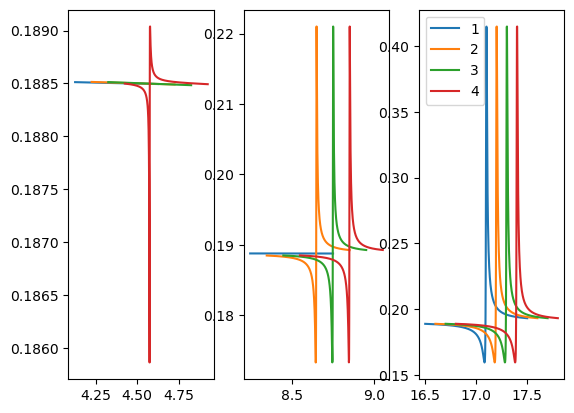

In [72]:
dot_norm = QD(-30, 100, np.array([0.5]), np.array([[2.0804273,  0.00000000,  5.7159271]]), np.array([[2.0, 2.0, 2.0]]))

NFs = [1,2,3,4]
Nint = 3e3
df = 0
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])
Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])

freq1 = np.linspace(4.125, 4.625, 500)
freq2 = np.linspace(8.25, 8.75, 500)
freq3 = np.linspace(16.5, 17.5, 500)

fig, ax = plt.subplots(1,3)

for NF in NFs:
    ts = time()

    I = ESR.ESR(Left, Right, dot, freq1, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq1, NFL=NF)
    ax[0].plot(freq1+df, (I-I_norm)[:, NF], label=f'{NF}')
    
    I = ESR.ESR(Left, Right, dot, freq2, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq2, NFL=NF)
    ax[1].plot(freq2+df, (I-I_norm)[:, NF], label=f'{NF}')
    
    I = ESR.ESR(Left, Right, dot, freq3, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq3, NFL=NF)
    ax[2].plot(freq3+df, (I-I_norm)[:, NF], label=f'{NF}')

    tf = time()
    print(f'NF={NF:d}: {tf-ts:.2f} s')
    df += .1

plt.legend()
plt.show()

## Fitting ESR 

Next we start fitting the signal. We fit `ESR_fit_fun()` for this purpuse. It is convinient to have an estimate of the initial parameters, as we do using `guess_p0()`, it gives a terrible estimate but it is usefull to get a correct order of magnitude of the parameters.

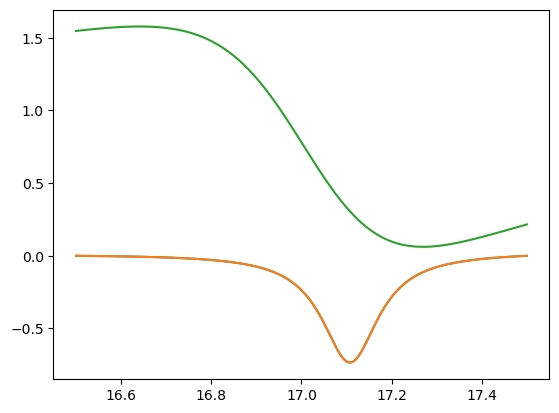

In [74]:
from scipy.optimize import curve_fit

Nint = 1e4
NF = 1
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])
Left = Electrode(-30, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300,  
                        segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])

freq = np.linspace(16.5, 17.5, 1000)
I = ESR.ESR(Left, Right, dot, freq, NFL=NF)
I_norm = ESR.ESR(Left, Right, dot_norm, freq, NFL=NF)
esr = np.real((I-I_norm)[:,NF])

Zeeman = dot.Delta[0,1]*units.Hartree/units.GHz
p0 = ESR.guess_p0(freq, esr, Zeeman) 
# This is a crap estimation but gives the correct order of magnitude

popt, pcov = curve_fit(ESR.ESR_fit_fun, freq, esr, p0=p0)
plt.plot(freq, esr)
plt.plot(freq, ESR.ESR_fit_fun(freq, *popt))
plt.plot(freq, ESR.ESR_fit_fun(freq, *p0))

In [76]:
Nint = 1e4
NF = 1
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])

Zeeman = dot.Delta[0,1]*units.Hartree/units.GHz
freq = np.linspace(16.5, 17.5, 500)

Vdcs = np.arange(-40, -20, 1.)
Lamb = np.empty_like(Vdcs)
Is = np.empty_like(Vdcs)
Ia = np.empty_like(Vdcs)
gamma = np.empty_like(Vdcs)

Lamb_pred = np.empty_like(Vdcs)
Bdrive = np.empty_like(Vdcs)
T1 = np.empty_like(Vdcs)
Sz0 = np.empty_like(Vdcs)
Sz1 = np.empty_like(Vdcs)

failed_fits = []

p0 = None
ts = time()
for i, Vdc in enumerate(Vdcs):
    Left = Electrode(Vdc, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300,  
            segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
    
    # it might be beter to not use this function for larger simulations as 
    # some calculations GR for example are being repeated. 
    I, GL, GR = ESR.ESR(Left, Right, dot, freq, NFL=NF, return_Gs=True)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq, NFL=NF)
    esr = np.real((I-I_norm)[:,NF])
    
    if p0 is None:
        p0 = ESR.guess_p0(freq, esr, Zeeman)
    try: 
        popt, pcov = curve_fit(ESR.ESR_fit_fun, freq, esr, p0=p0, maxfev=int(1e4))
        p0 = popt # We use the results as an estimate for the next guess
    except:
        print(f'Fitting Falied for VDC={Vdc:.1f}')
        popt = np.array([None]*len(p0))
        failed_fits.append([Vdc, esr])

    Lamb[i], gamma[i], Is[i], Ia[i] = popt[:4]

    Lamb_pred[i] = Bexch(GL, GR, dot.theta)*units.Hartree/units.GHz
    Bdrive[i] = Bexch(GL, GR, dot.theta, n=1)*units.Hartree/units.GHz
    T1[i] = Trel(GL, GR)*units.Hartree/units.GHz
    Sz0[i] = Szacc(GL, GR, rho, Left.Spin_polarization, dot.theta)*units.Hartree/units.GHz
    Sz1[i] = Szacc(GL, GR, rho, Left.Spin_polarization, dot.theta, n=1)*units.Hartree/units.GHz

tf = time()

Lamb -= Zeeman
Ia *= np.sign(gamma) # gamma can be negative somtimes
gamma *= np.sign(gamma) # gamma can be negative somtimes

tt = tf-ts
print(f'{len(Vdcs):d} calculations took {tt:.2f}s')
print(f'{tt/len(Vdcs)}s per calculaction.')

20 calculations took 91.70s
4.584958255290985s per calculaction.


/tmp/ipykernel_235660/3442492113.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


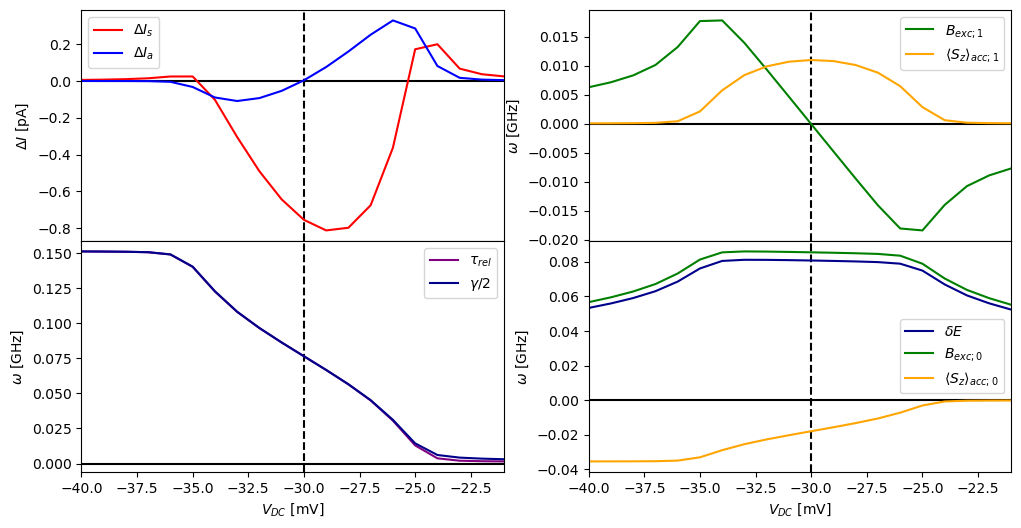

In [77]:
fig,ax = plt.subplots(2,2, figsize=(12,6), sharex=True)
ax= ax.flatten()
plt.subplots_adjust(hspace=0)

ax[3].plot(Vdcs, Lamb, 'darkblue', label=r'$\delta E$')
ax[3].plot(Vdcs, Lamb_pred, 'g', label=r'$B_{exc;0}$')
ax[3].plot(Vdcs, Sz0, 'orange', label=r'$\langle S_z \rangle_{acc;0}$')
ax[2].plot(Vdcs,  T1, 'purple', label=r'$\tau_{rel}$')
ax[2].plot(Vdcs, gamma/2, 'darkblue', label=r'$\gamma/2$')

ax[0].plot(Vdcs, Is, 'r', label=r'$\Delta I_s$')
ax[0].plot(Vdcs, Ia, 'b', label=r'$\Delta I_a$')
ax[1].plot(Vdcs, Bdrive, 'g', label=r'$B_{exc;1}$')
ax[1].plot(Vdcs, Sz1, 'orange', label=r'$\langle S_z \rangle_{acc;1}$')

for a in ax.flatten():
    a.set_xlim(-40, -21)
    xlim, ylim = a.get_xlim(), a.get_ylim()
    a.autoscale(False)

    #a.scatter([-35, -25], [0,0], c='black', marker='x', label=r'$\epsilon \pm V_{RF}$')
    a.hlines([0], xlim[0], xlim[1], 'k', '-', zorder=-1)
    a.vlines([-30], ylim[0], ylim[1], 'k', '--', zorder=-1)
    a.legend()

ax[2].set_ylabel(r'$\omega$ [GHz]')
ax[1].set_ylabel(r'$\omega$ [GHz]')
ax[3].set_ylabel(r'$\omega$ [GHz]')
ax[0].set_ylabel(r'$\Delta I$ [pA]')
ax[2].set_xlabel(r'$V_{DC}$ [mV]')
ax[3].set_xlabel(r'$V_{DC}$ [mV]')

fig.show()